In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [2]:
RANDOM_SEED = 42

In [3]:
!wget https://www.cis.fordham.edu/wisdm/includes/datasets/latest/WISDM_ar_latest.tar.gz

--2026-04-17 16:19:54--  https://www.cis.fordham.edu/wisdm/includes/datasets/latest/WISDM_ar_latest.tar.gz
Resolving www.cis.fordham.edu (www.cis.fordham.edu)... 150.108.68.29
Connecting to www.cis.fordham.edu (www.cis.fordham.edu)|150.108.68.29|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11404612 (11M) [application/x-gzip]
Saving to: ‘WISDM_ar_latest.tar.gz’

WISDM_ar_latest.tar 100%[===================>]  10.88M  32.0MB/s    in 0.3s    

2026-04-17 16:19:54 (32.0 MB/s) - ‘WISDM_ar_latest.tar.gz’ saved [11404612/11404612]



In [4]:
import os

os.listdir()

['.config', 'WISDM_ar_latest.tar.gz', 'sample_data']

In [5]:
!tar -xvzf WISDM_ar_latest.tar.gz

WISDM_ar_v1.1/
WISDM_ar_v1.1/readme.txt
WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt
WISDM_ar_v1.1/WISDM_ar_v1.1_raw_about.txt
WISDM_ar_v1.1/WISDM_ar_v1.1_transformed.arff
WISDM_ar_v1.1/WISDM_ar_v1.1_trans_about.txt


In [6]:
os.listdir("WISDM_ar_v1.1")

['WISDM_ar_v1.1_raw.txt',
 'readme.txt',
 'WISDM_ar_v1.1_trans_about.txt',
 'WISDM_ar_v1.1_raw_about.txt',
 'WISDM_ar_v1.1_transformed.arff']

In [7]:
df = pd.read_csv(
    "WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt",
    header=None,
    names=["user", "activity", "timestamp", "x_axis", "y_axis", "z_axis"],
    sep=",",
    engine="python",
    on_bad_lines="skip"
)

In [8]:
df = df.dropna()

In [9]:
df.head()

,user,activity,timestamp,x_axis,y_axis,z_axis
0,33,Jogging,49105962326000,-0.694638,12.680544,0.50395286;
1,33,Jogging,49106062271000,5.012288,11.264028,0.95342433;
2,33,Jogging,49106112167000,4.903325,10.882658,-0.08172209;
3,33,Jogging,49106222305000,-0.612916,18.496431,3.0237172;
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164;


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1086465 entries, 0 to 1086465
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user       1086465 non-null  int64  
 1   activity   1086465 non-null  object 
 2   timestamp  1086465 non-null  int64  
 3   x_axis     1086465 non-null  float64
 4   y_axis     1086465 non-null  float64
 5   z_axis     1086465 non-null  object 
dtypes: float64(2), int64(2), object(2)
memory usage: 58.0+ MB


In [11]:
df['z_axis'] = df['z_axis'].str.replace(';', '', regex=False).astype(float)

In [12]:
df['activity'].value_counts()

,count
activity,
Walking,418393
Jogging,336445
Upstairs,122869
Downstairs,100425
Sitting,59939
Standing,48394


<Axes: xlabel='activity'>

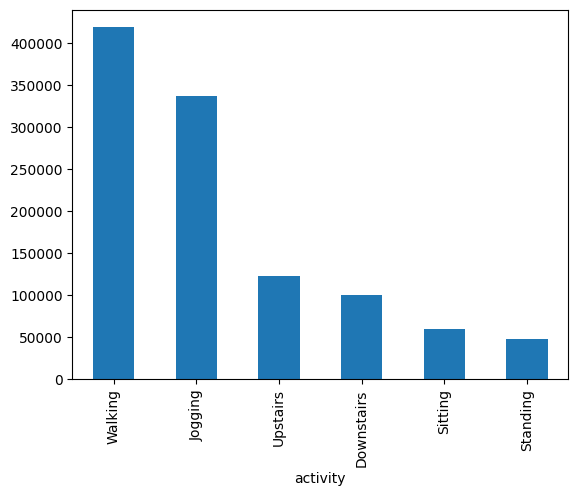

In [13]:
df['activity'].value_counts().plot(kind = 'bar')

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

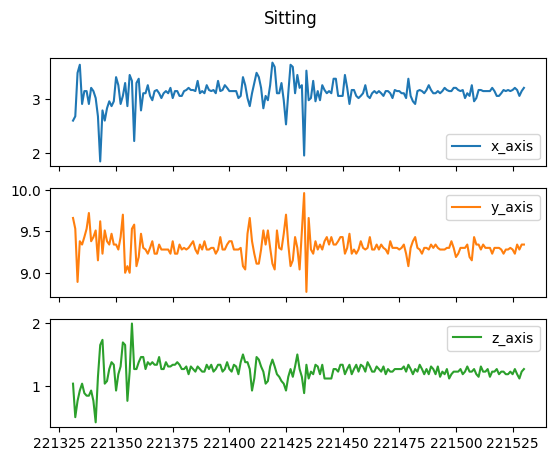

In [14]:
d1 = df[df['activity']=='Sitting']
(d1[['x_axis',	'y_axis',	'z_axis']][:200]).plot(subplots=True, title = 'Sitting')

In [15]:
import matplotlib.pyplot as plt

def plot_activity(activity, data=df):
    # 1. Filter rows where the 'activity' column matches the input
    extractRowsOfActivity = (df['activity'] == activity) #true/False

    # 2. Create a subset of the dataframe with those rows
    data = df[extractRowsOfActivity]

    # 3. Select only the sensor coordinate columns
    data = data[['x_axis', 'y_axis', 'z_axis']]

    # 4. Limit the data to the first 200 rows for better visualization
    data = data[:200]

    # 5. Plot each column as a separate subplot
    ax = data.plot(subplots=True, figsize=(16, 12), title=activity)

    plt.show() # Added to ensure the plot displays


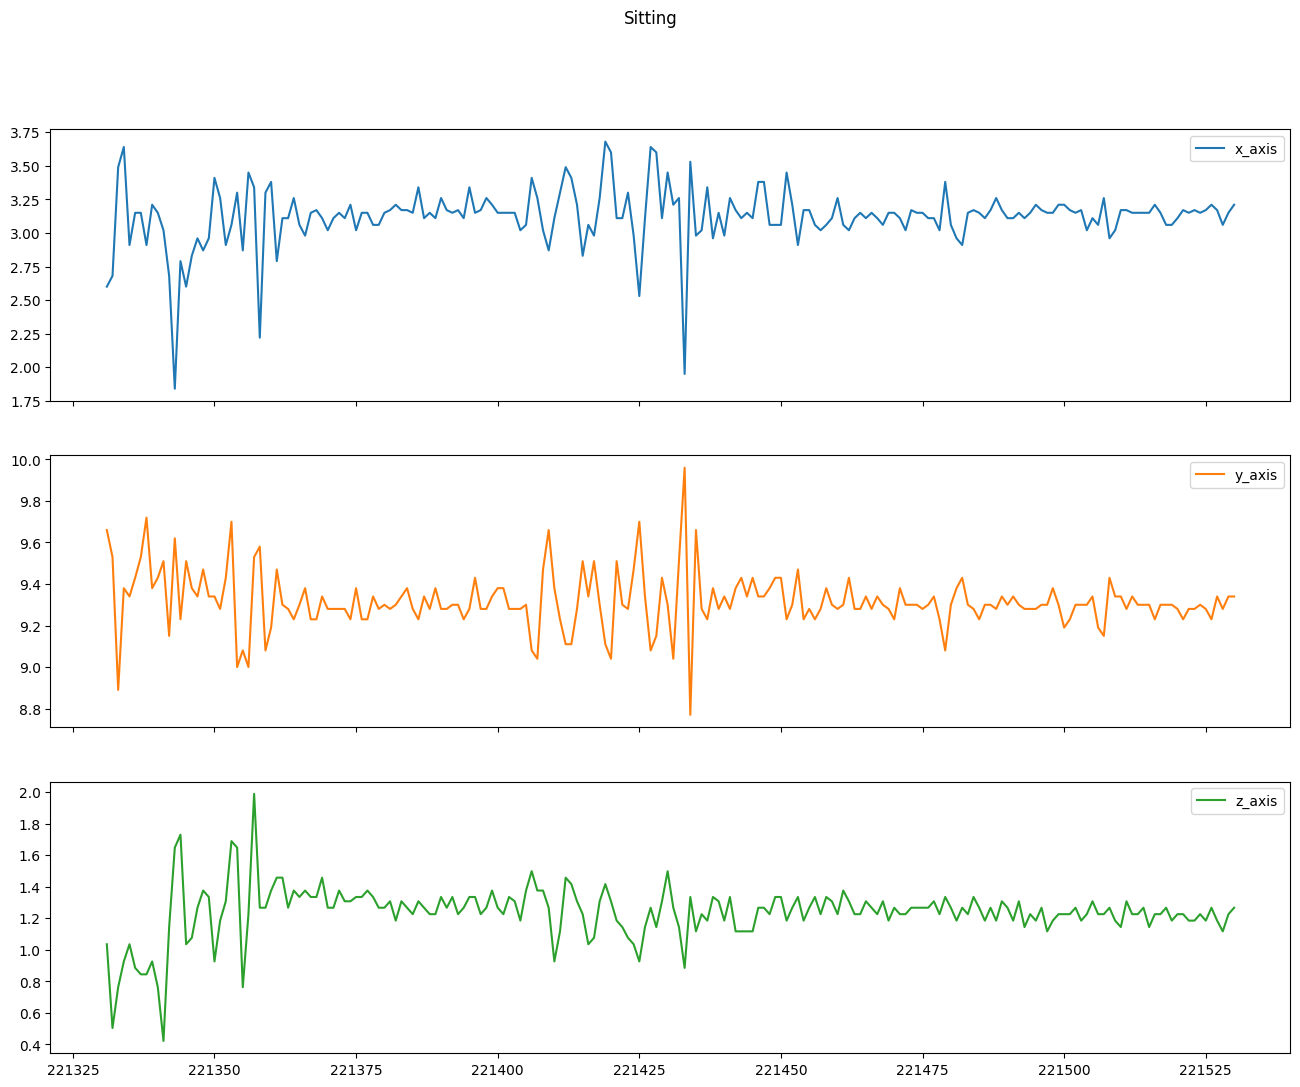

In [16]:
plot_activity('Sitting', df)

In [17]:
N_TIME_STEPS =200
N_FEATURES = 3
Step = 20
segments = []
labels = []

In [18]:
from scipy import stats

In [19]:
window = df['activity'].iloc[0: 0 + N_TIME_STEPS]
values, counts = np.unique(window, return_counts=True)
values[np.argmax(counts)]



'Jogging'

In [20]:
label = np.unique(window, return_counts=True)[0][np.argmax(np.unique(window, return_counts=True)[1])]
label

'Jogging'

In [21]:
for i in range(0, len(df) - N_TIME_STEPS, Step):
    xs = df['x_axis'].values[i : i + N_TIME_STEPS]
    ys = df['y_axis'].values[i : i + N_TIME_STEPS]
    zs = df['z_axis'].values[i : i + N_TIME_STEPS]

    window = df['activity'].iloc[i : i + N_TIME_STEPS]

    values, counts = np.unique(window, return_counts=True)
    label = values[np.argmax(counts)]

    segments.append([xs, ys, zs])
    labels.append(label)

In [22]:
np.array(segments).shape

(54314, 3, 200)

In [23]:
reshaped_segmentes = np.asarray(segments).transpose(0, 2, 1)

In [24]:
reshaped_segmentes.shape

(54314, 200, 3)

In [25]:
labels = np.asarray(pd.get_dummies(labels)).astype(int)

In [26]:
labels.shape

(54314, 6)

In [27]:
labels[0]

array([0, 1, 0, 0, 0, 0])

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    reshaped_segmentes,
    labels,
    test_size=0.2,
    random_state=RANDOM_SEED
)

In [29]:
len(X_train)

43451

In [30]:
len(X_test)

10863

In [33]:
N_CLASSES = 6
N_HIDDEN_UNITS = 64

In [36]:
import tensorflow as tf

def create_lstm_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(N_TIME_STEPS, N_FEATURES)),

        # First LSTM layer (64 hidden units)
        tf.keras.layers.LSTM(
            64,
            return_sequences=True
        ),

        # Second LSTM layer (64 hidden units)
        tf.keras.layers.LSTM(
            64
        ),

        # Output layer
        tf.keras.layers.Dense(
            N_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Create model
model = create_lstm_model()

# Show architecture
model.summary()

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 200, 64)        │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,822 (198.52 KB)

 Trainable params: 50,822 (198.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 197s 284ms/step - accuracy: 0.7903 - loss: 0.5961 - val_accuracy: 0.8536 - val_loss: 0.3849
Epoch 2/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 197s 277ms/step - accuracy: 0.8735 - loss: 0.3522 - val_accuracy: 0.9141 - val_loss: 0.2422
Epoch 3/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 192s 283ms/step - accuracy: 0.9298 - loss: 0.2019 - val_accuracy: 0.9307 - val_loss: 0.2054
Epoch 4/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 203s 284ms/step - accuracy: 0.9475 - loss: 0.1564 - val_accuracy: 0.9610 - val_loss: 0.1109
Epoch 5/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 205s 288ms/step - accuracy: 0.9550 - loss: 0.1364 - val_accuracy: 0.8610 - val_loss: 0.3779
Epoch 6/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 197s 280ms/step - accuracy: 0.9457 - loss: 0.1681 - val_accuracy: 0.9706 - val_loss: 0.0915
Epoch 7/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 201s 279ms/step - accuracy: 0.9696 - loss: 0.0916 - val_accuracy: 0.9772 - val_loss: 0.0670
Epoch 8/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 201s 279ms/step - accuracy: 0.9763 -

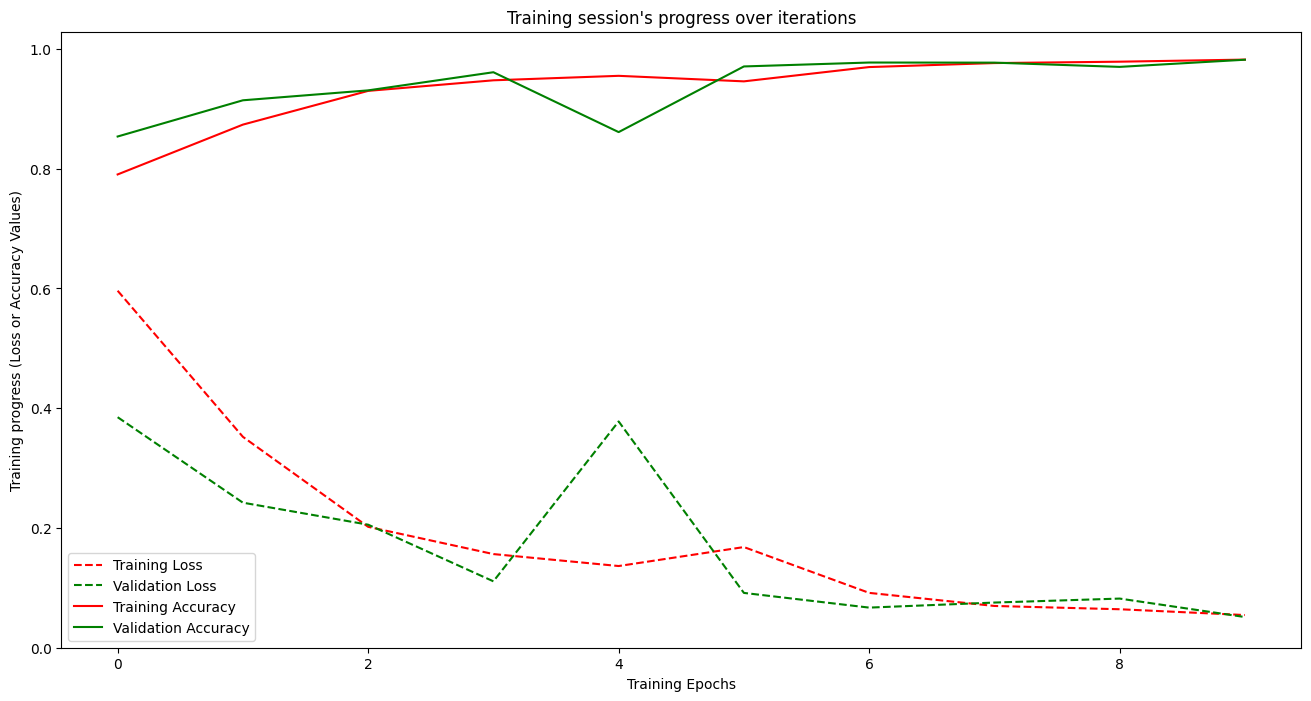

In [37]:
plt.figure(figsize = (16, 8))


plt.plot(history.history['loss'],'r--' ,label = 'Training Loss')
plt.plot(history.history['val_loss'], 'g--' ,label = 'Validation Loss')

plt.plot(history.history['accuracy'], 'r-' ,label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], 'g-' ,label = 'Validation Accuracy')

plt.title("Training session's progress over iterations")
plt.legend()
plt.xlabel('Training Epochs')
plt.ylabel('Training progress (Loss or Accuracy Values)')
plt.ylim(0)
plt.show()

# Save and convert to standard TFLite

In [38]:
model.save('lstm_har_model.keras')

In [40]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

Saved artifact at '/tmp/tmp4umwwmfh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 3), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134049419902608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049419902800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049419901456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049444397328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049444397520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049444399248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049444399440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049444397136: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [41]:
type(tflite_model)

bytes

In [42]:
with open('lstm_har_float32.tflite', 'wb') as f:
    f.write(tflite_model)

In [43]:
print(f"Float32 model size: {len(tflite_model) / 1024:.2f} KB")

Float32 model size: 217.26 KB


#  Convert with INT8 quantization

In [45]:
converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
converter_q.representative_dataset = representative_dataset

# These two lines fix the TensorListReserve error
converter_q.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter_q._experimental_lower_tensor_list_ops = False

tflite_model_int8 = converter_q.convert()

with open('lstm_har_int8.tflite', 'wb') as f:
    f.write(tflite_model_int8)

print(f"Quantized model size: {len(tflite_model_int8) / 1024:.2f} KB")

Saved artifact at '/tmp/tmp1cxhvp1j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 3), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134049419902608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049419902800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049419901456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049444397328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049444397520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049444399248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049444399440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049444397136: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized model size: 87.73 KB


# GRU Model for full INT8 quantization

```
# This is formatted as code
```




In [51]:
tf.keras.backend.clear_session()

In [57]:
import tensorflow as tf

def create_gru_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(N_TIME_STEPS, N_FEATURES)),

        # First GRU layer (64 hidden units)
        tf.keras.layers.GRU(
            64,
            return_sequences=True,
            unroll = True
        ),

        # Second GRU layer (64 hidden units)
        tf.keras.layers.GRU(
            64,
            unroll = True
        ),

        # Output layer
        tf.keras.layers.Dense(
            N_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Create model
model = create_gru_model()

# Show architecture
model.summary()

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 200, 64)        │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,598 (150.77 KB)

 Trainable params: 38,598 (150.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 358s 309ms/step - accuracy: 0.8441 - loss: 0.4399 - val_accuracy: 0.9287 - val_loss: 0.1992
Epoch 2/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 234s 268ms/step - accuracy: 0.9514 - loss: 0.1377 - val_accuracy: 0.9631 - val_loss: 0.1023
Epoch 3/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 184s 272ms/step - accuracy: 0.9712 - loss: 0.0811 - val_accuracy: 0.9757 - val_loss: 0.0683
Epoch 4/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 181s 266ms/step - accuracy: 0.9806 - loss: 0.0555 - val_accuracy: 0.9855 - val_loss: 0.0426
Epoch 5/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 208s 275ms/step - accuracy: 0.9851 - loss: 0.0439 - val_accuracy: 0.9900 - val_loss: 0.0313
340/340 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9900 - loss: 0.0313
Test Accuracy: 0.9899659156799316


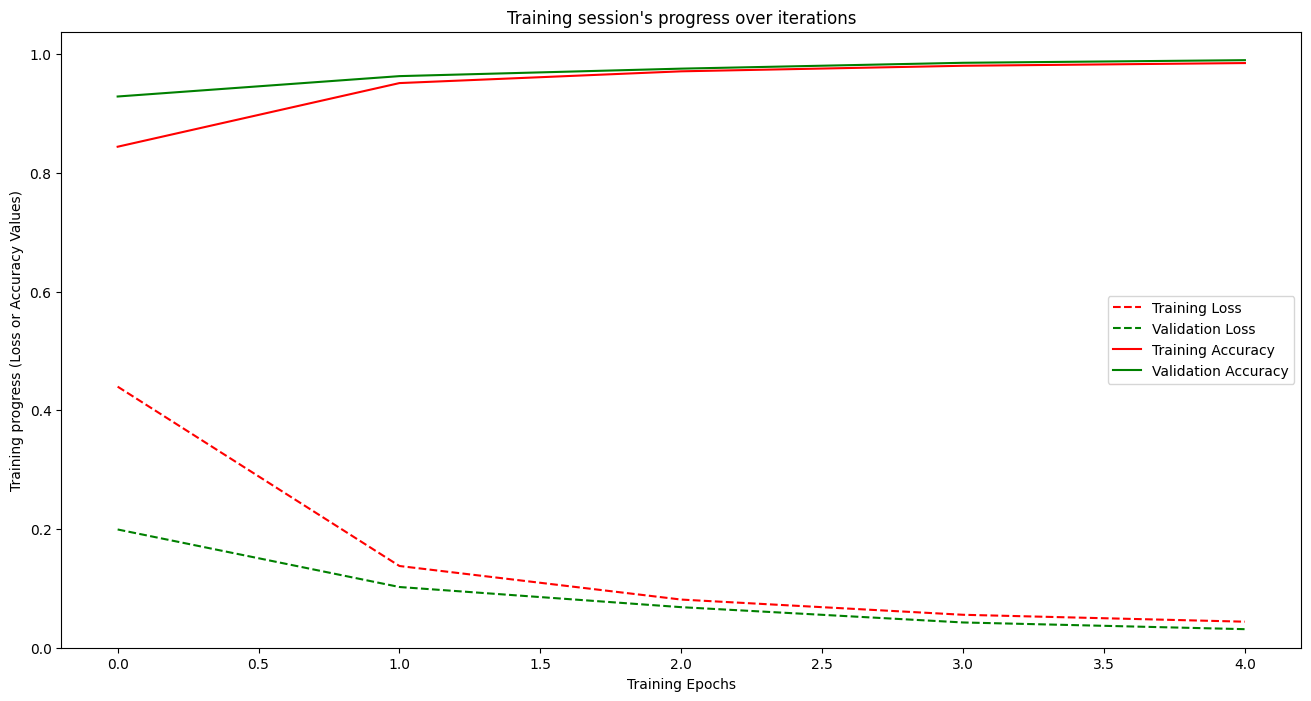

In [58]:
plt.figure(figsize = (16, 8))


plt.plot(history.history['loss'],'r--' ,label = 'Training Loss')
plt.plot(history.history['val_loss'], 'g--' ,label = 'Validation Loss')

plt.plot(history.history['accuracy'], 'r-' ,label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], 'g-' ,label = 'Validation Accuracy')

plt.title("Training session's progress over iterations")
plt.legend()
plt.xlabel('Training Epochs')
plt.ylabel('Training progress (Loss or Accuracy Values)')
plt.ylim(0)
plt.show()

In [59]:
# Save the trained model first
model.save('gru_har_model.keras')

# Convert to TFLite (float32 baseline)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('gru_har_float32.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Float32 model size: {len(tflite_model) / 1024:.2f} KB")

Saved artifact at '/tmp/tmp4rhfqf51'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 3), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134049487072784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487069904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487071056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487073360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487072976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487070288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487073552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487071824: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float32 model size: 1457.45 KB


In [60]:
import numpy as np

# Representative dataset tells the converter what real input values look like
# Use a sample of your training data (100-200 samples is enough)
def representative_dataset():
    for i in range(200):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

# INT8 quantization converter
converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
converter_q.representative_dataset = representative_dataset
converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_q.inference_input_type = tf.int8
converter_q.inference_output_type = tf.int8

tflite_model_int8 = converter_q.convert()

with open('gru_har_int8.tflite', 'wb') as f:
    f.write(tflite_model_int8)

print(f"INT8 model size: {len(tflite_model_int8) / 1024:.2f} KB")

Saved artifact at '/tmp/tmpl05p6y4d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 3), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134049487072784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487069904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487071056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487073360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487072976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487070288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487073552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487071824: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 model size: 6319.91 KB


# Convert .tflite model to a C byte array

In [61]:
with open('lstm_har_int8.tflite', 'rb') as f:
    model_bytes = f.read()

# Convert to C array
c_array = ', '.join([f'0x{b:02x}' for b in model_bytes])

c_code = f"""
#ifndef LSTM_MODEL_H
#define LSTM_MODEL_H

const unsigned char lstm_model[] = {{
  {c_array}
}};
const unsigned int lstm_model_len = {len(model_bytes)};

#endif
"""

with open('lstm_model.h', 'w') as f:
    f.write(c_code)

print(f"Model array written — {len(model_bytes)} bytes")

Model array written — 89840 bytes


In [65]:
import numpy as np
import time

# --- Float32 inference ---
interpreter_f32 = tf.lite.Interpreter(model_path='gru_har_float32.tflite')
interpreter_f32.allocate_tensors()
input_details_f32 = interpreter_f32.get_input_details()
output_details_f32 = interpreter_f32.get_output_details()

# --- INT8 inference ---
interpreter_int8 = tf.lite.Interpreter(model_path='gru_har_int8.tflite')
interpreter_int8.allocate_tensors()
input_details_int8 = interpreter_int8.get_input_details()
output_details_int8 = interpreter_int8.get_output_details()

# Pick one test sample
sample = X_test[0:1].astype(np.float32)

# Float32 timing
start = time.perf_counter()
for _ in range(100):
    interpreter_f32.set_tensor(input_details_f32[0]['index'], sample)
    interpreter_f32.invoke()
f32_time = (time.perf_counter() - start) / 100 * 1000  # ms

# INT8 timing (input needs to be int8)
scale, zero_point = input_details_int8[0]['quantization']
sample_int8 = (sample / scale + zero_point).astype(np.int8)

start = time.perf_counter()
for _ in range(100):
    interpreter_int8.set_tensor(input_details_int8[0]['index'], sample_int8)
    interpreter_int8.invoke()
int8_time = (time.perf_counter() - start) / 100 * 1000  # ms

# Accuracy on full test set (float32)
correct = 0
for i in range(len(X_test)):
    s = X_test[i:i+1].astype(np.float32)
    interpreter_f32.set_tensor(input_details_f32[0]['index'], s)
    interpreter_f32.invoke()
    pred = np.argmax(interpreter_f32.get_tensor(output_details_f32[0]['index']))
    if pred == np.argmax(y_test[i]):
        correct += 1
f32_acc = correct / len(X_test) * 100

# Accuracy on full test set (int8)
correct = 0
for i in range(len(X_test)):
    s = X_test[i:i+1].astype(np.float32)
    s_int8 = (s / scale + zero_point).astype(np.int8)
    interpreter_int8.set_tensor(input_details_int8[0]['index'], s_int8)
    interpreter_int8.invoke()
    out = interpreter_int8.get_tensor(output_details_int8[0]['index'])
    pred = np.argmax(out)
    if pred == np.argmax(y_test[i]):
        correct += 1
int8_acc = correct / len(X_test) * 100

import os
f32_size = os.path.getsize('gru_har_float32.tflite') / 1024
int8_size = os.path.getsize('gru_har_int8.tflite') / 1024

print("=" * 45)
print(f"{'Metric':<25} {'Float32':>8} {'INT8':>8}")
print("=" * 45)
print(f"{'Model Size (KB)':<25} {f32_size:>8.2f} {int8_size:>8.2f}")
print(f"{'Accuracy (%)':<25} {f32_acc:>8.2f} {int8_acc:>8.2f}")
print(f"{'Avg Inference (ms)':<25} {f32_time:>8.3f} {int8_time:>8.3f}")
print(f"{'Size Reduction':<25} {f32_size/int8_size:>8.2f}x")
print("=" * 45)

Metric                     Float32     INT8
Model Size (KB)            1457.45  6319.91
Accuracy (%)                 99.00    97.55
Avg Inference (ms)           9.502   13.201
Size Reduction                0.23x


# CNN-GRU Model

In [73]:
N_TIME_STEPS = 200  # keep as is
N_FEATURES = 3

def create_cnn_gru_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(N_TIME_STEPS, N_FEATURES)),

        # 200 → 49 timesteps
        tf.keras.layers.Conv1D(32, kernel_size=5, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=4),

        # 49 → 23 timesteps
        tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),

        # GRU only sees ~23 timesteps — safe to unroll
        tf.keras.layers.GRU(32),

        tf.keras.layers.Dense(N_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [74]:
# Create model
model = create_cnn_gru_model()

# Show architecture
model.summary()

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 196, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 47, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,326 (63.77 KB)

 Trainable params: 16,326 (63.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.8778 - loss: 0.3485 - val_accuracy: 0.9531 - val_loss: 0.1494
Epoch 2/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.9584 - loss: 0.1168 - val_accuracy: 0.9733 - val_loss: 0.0757
Epoch 3/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 45s 40ms/step - accuracy: 0.9743 - loss: 0.0737 - val_accuracy: 0.9813 - val_loss: 0.0539
Epoch 4/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.9820 - loss: 0.0507 - val_accuracy: 0.9840 - val_loss: 0.0457
Epoch 5/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.9852 - loss: 0.0426 - val_accuracy: 0.9854 - val_loss: 0.0357
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9854 - loss: 0.0357
Test Accuracy: 0.9853631854057312


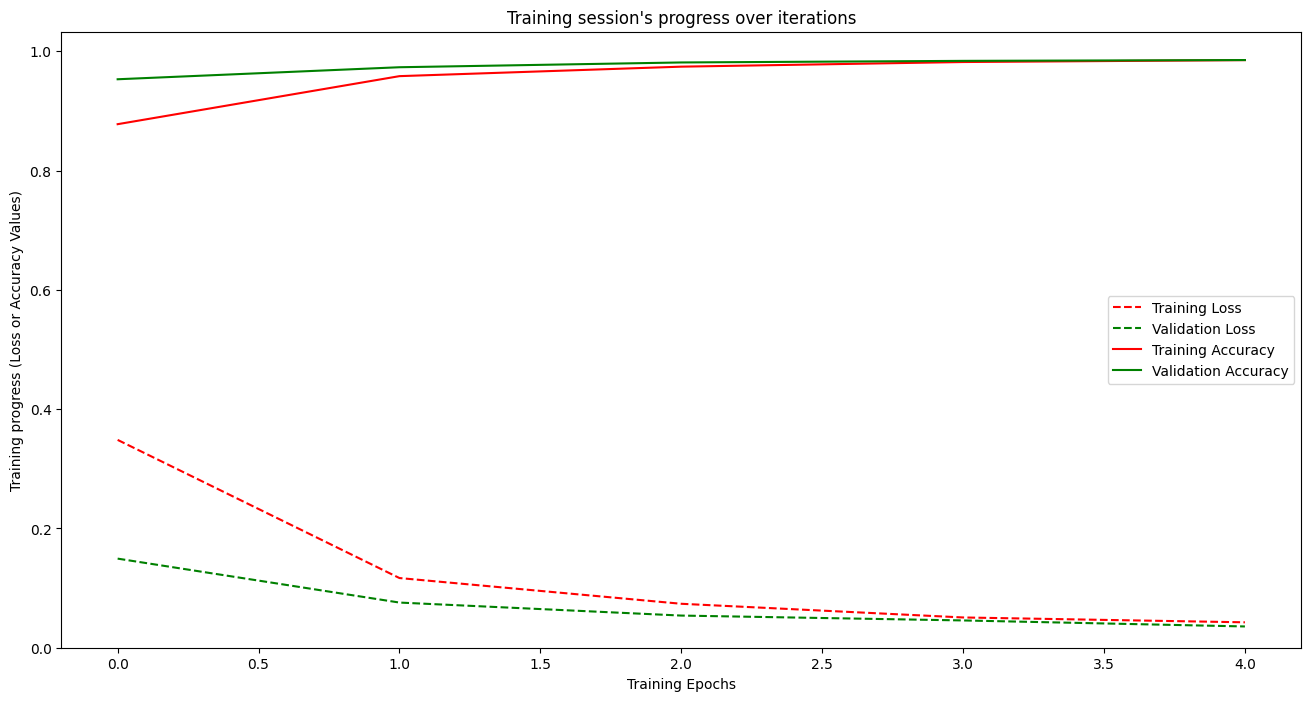

In [75]:
plt.figure(figsize = (16, 8))


plt.plot(history.history['loss'],'r--' ,label = 'Training Loss')
plt.plot(history.history['val_loss'], 'g--' ,label = 'Validation Loss')

plt.plot(history.history['accuracy'], 'r-' ,label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], 'g-' ,label = 'Validation Accuracy')

plt.title("Training session's progress over iterations")
plt.legend()
plt.xlabel('Training Epochs')
plt.ylabel('Training progress (Loss or Accuracy Values)')
plt.ylim(0)
plt.show()

In [77]:
# Save the trained model first
model.save('cnn_gru_har_model.keras')

f32_size = os.path.getsize('cnn_gru_har_float32.tflite') / 1024
print(f"Float32 size: {f32_size:.2f} KB")

Float32 size: 145.10 KB


In [78]:
def representative_dataset():
    for i in range(200):
        yield [X_train[i:i+1].astype(np.float32)]

converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
converter_q.representative_dataset = representative_dataset
converter_q.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter_q._experimental_lower_tensor_list_ops = False
converter_q.inference_input_type = tf.float32
converter_q.inference_output_type = tf.float32

tflite_int8 = converter_q.convert()
with open('cnn_gru_int8.tflite', 'wb') as f:
    f.write(tflite_int8)
print(f"INT8 size: {len(tflite_int8)/1024:.2f} KB")


Saved artifact at '/tmp/tmpa2ew4qgj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 3), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134049551862864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049519966864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049551861712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134049487074704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134047990551312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134047990552080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134047990547856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134047990551120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134047990551696: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 size: 42.42 KB


In [79]:
# ── Load both interpreters ────────────────────────────────────
interpreter_f32 = tf.lite.Interpreter(model_path='cnn_gru_har_float32.tflite')
interpreter_f32.allocate_tensors()
input_f32  = interpreter_f32.get_input_details()
output_f32 = interpreter_f32.get_output_details()

interpreter_int8 = tf.lite.Interpreter(model_path='cnn_gru_int8.tflite')
interpreter_int8.allocate_tensors()
input_int8  = interpreter_int8.get_input_details()
output_int8 = interpreter_int8.get_output_details()

# ── Speed ─────────────────────────────────────────────────────
sample = X_test[0:1].astype(np.float32)

start = time.perf_counter()
for _ in range(100):
    interpreter_f32.set_tensor(input_f32[0]['index'], sample)
    interpreter_f32.invoke()
f32_time = (time.perf_counter() - start) / 100 * 1000

start = time.perf_counter()
for _ in range(100):
    interpreter_int8.set_tensor(input_int8[0]['index'], sample)
    interpreter_int8.invoke()
int8_time = (time.perf_counter() - start) / 100 * 1000

# ── Accuracy ──────────────────────────────────────────────────
correct_f32 = correct_int8 = 0
for i in range(len(X_test)):
    s = X_test[i:i+1].astype(np.float32)

    interpreter_f32.set_tensor(input_f32[0]['index'], s)
    interpreter_f32.invoke()
    if np.argmax(interpreter_f32.get_tensor(output_f32[0]['index'])) == np.argmax(y_test[i]):
        correct_f32 += 1

    interpreter_int8.set_tensor(input_int8[0]['index'], s)
    interpreter_int8.invoke()
    if np.argmax(interpreter_int8.get_tensor(output_int8[0]['index'])) == np.argmax(y_test[i]):
        correct_int8 += 1

f32_acc  = correct_f32  / len(X_test) * 100
int8_acc = correct_int8 / len(X_test) * 100
int8_size = os.path.getsize('cnn_gru_int8.tflite') / 1024

# ── Table ─────────────────────────────────────────────────────
print("\n" + "=" * 45)
print(f"{'Metric':<25} {'Float32':>8} {'INT8':>8}")
print("=" * 45)
print(f"{'Model Size (KB)':<25} {f32_size:>8.2f} {int8_size:>8.2f}")
print(f"{'Accuracy (%)':<25} {f32_acc:>8.2f} {int8_acc:>8.2f}")
print(f"{'Avg Inference (ms)':<25} {f32_time:>8.3f} {int8_time:>8.3f}")
print(f"{'Size Reduction':<25} {f32_size/int8_size:>8.2f}x")
print("=" * 45)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Metric                     Float32     INT8
Model Size (KB)             145.10    42.42
Accuracy (%)                 98.75    98.46
Avg Inference (ms)           0.436    1.889
Size Reduction                3.42x


In [81]:
print(df['activity'].unique())

['Jogging' 'Walking' 'Upstairs' 'Downstairs' 'Sitting' 'Standing']


In [82]:
import numpy as np

# Pick 6 samples, one per class
samples_per_class = {}
for i in range(len(X_test)):
    label = np.argmax(y_test[i])
    if label not in samples_per_class:
        samples_per_class[label] = X_test[i]
    if len(samples_per_class) == 6:
        break

activity_names = ['Jogging', 'Walking', 'Upstairs', 'Downstairs', 'Sitting', 'Standing']

# Print as C array
print("float test_samples[6][200][3] = {")
for cls_idx in range(6):
    sample = samples_per_class[cls_idx]
    print("  {  // " + activity_names[cls_idx])
    for timestep in sample:
        print(f"    {{{timestep[0]:.6f}f, {timestep[1]:.6f}f, {timestep[2]:.6f}f}},")
    print("  },")
print("};")

float test_samples[6][200][3] = {
  {  // Jogging
    {-1.080000f, 9.890000f, 3.486809f},
    {-1.460000f, 6.280000f, 2.029432f},
    {1.330000f, 6.050000f, 1.729784f},
    {1.330000f, 5.010000f, 1.334794f},
    {-0.720000f, 5.860000f, 0.803601f},
    {-0.720000f, 5.860000f, 0.803601f},
    {-1.950000f, 9.530000f, 4.440233f},
    {0.690000f, 14.250000f, 5.094010f},
    {-4.100000f, 8.120000f, -4.903325f},
    {0.110000f, 14.330000f, 4.562817f},
    {-4.400000f, 10.730000f, -0.503953f},
    {-3.870000f, 10.920000f, 2.492524f},
    {-0.420000f, 8.660000f, 0.885323f},
    {-1.920000f, 6.700000f, 2.792171f},
    {-2.680000f, 7.120000f, 1.879608f},
    {-4.330000f, 7.670000f, 2.301839f},
    {-3.490000f, 9.040000f, 1.688923f},
    {-0.230000f, 14.710000f, 3.255263f},
    {-2.450000f, 13.570000f, 4.372132f},
    {-1.140000f, 11.350000f, 4.481094f},
    {-0.840000f, 8.350000f, 3.064578f},
    {0.340000f, 4.900000f, 1.566340f},
    {0.110000f, 4.480000f, 1.920469f},
    {-2.110000f, 7.060000f,

In [83]:
import tensorflow as tf
import numpy as np
import time

activity_names = ['Jogging', 'Walking', 'Upstairs', 'Downstairs', 'Sitting', 'Standing']

interpreter = tf.lite.Interpreter(model_path='cnn_gru_int8.tflite')
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Pick one sample per class
samples_per_class = {}
for i in range(len(X_test)):
    label = np.argmax(y_test[i])
    if label not in samples_per_class:
        samples_per_class[label] = (X_test[i], label)
    if len(samples_per_class) == 6:
        break

print("=================================")
print(" CNN-GRU HAR - ESP32 Simulation")
print(" Edge AI Inference Demo")
print("=================================\n")
print("Model : CNN-GRU INT8 Quantized")
print("Size  : 42.42 KB")
print("Accuracy: 98.46%")
print("---------------------------------\n")

for cls_idx in range(6):
    sample, true_label = samples_per_class[cls_idx]
    s = sample[np.newaxis, ...].astype(np.float32)

    start = time.perf_counter()
    interpreter.set_tensor(input_details[0]['index'], s)
    interpreter.invoke()
    duration_us = (time.perf_counter() - start) * 1_000_000

    output = interpreter.get_tensor(output_details[0]['index'])
    predicted = np.argmax(output)
    confidence = output[0][predicted] * 100

    print(f"Input:      {activity_names[true_label]} sample")
    print(f"Predicted:  {activity_names[predicted]}")
    print(f"True Label: {activity_names[true_label]}")
    print(f"Confidence: {confidence:.1f}%")
    print(f"Inference:  {duration_us:.1f} us")
    print(f"Result:     {'CORRECT ✓' if predicted == true_label else 'INCORRECT ✗'}")
    print("---------------------------------")

 CNN-GRU HAR - ESP32 Simulation
 Edge AI Inference Demo

Model : CNN-GRU INT8 Quantized
Size  : 42.42 KB
Accuracy: 98.46%
---------------------------------

Input:      Jogging sample
Predicted:  Jogging
True Label: Jogging
Confidence: 99.6%
Inference:  5013.1 us
Result:     CORRECT ✓
---------------------------------
Input:      Walking sample
Predicted:  Walking
True Label: Walking
Confidence: 99.6%
Inference:  1709.6 us
Result:     CORRECT ✓
---------------------------------
Input:      Upstairs sample
Predicted:  Upstairs
True Label: Upstairs
Confidence: 99.6%
Inference:  1371.4 us
Result:     CORRECT ✓
---------------------------------
Input:      Downstairs sample
Predicted:  Downstairs
True Label: Downstairs
Confidence: 99.2%
Inference:  1423.7 us
Result:     CORRECT ✓
---------------------------------
Input:      Sitting sample
Predicted:  Sitting
True Label: Sitting
Confidence: 99.6%
Inference:  1147.2 us
Result:     CORRECT ✓
---------------------------------
Input:      Stan

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
